In [ ]:
import pandas as pd
import numpy as np

#carregando o dataset
file_inmet = '/content/drive/MyDrive/Pivic/dados/Dados/Institudo de Metereologia/dados 2024/INMET_NE_PB_A313_CAMPINA GRANDE_01-01-2024_A_31-12-2024.CSV'

df_clima = pd.read_csv(file_inmet,
                       sep=';',
                       decimal=',',
                       skiprows=8,
                       encoding='latin1')
# selecionando as colunas que serão úteis
colunas_map = {
    'Data': 'DATA',
    'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'CHUVA_TOTAL',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'TEMP_MEDIA',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)': 'TEMP_MAX',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)': 'TEMP_MIN',
    'UMIDADE RELATIVA DO AR, HORARIA (%)': 'UMIDADE'
}
df_clima = df_clima.rename(columns=colunas_map)[colunas_map.values()]


#tratando irregularidade

df_clima['DATA'] = pd.to_datetime(df_clima['DATA'], format='%Y/%m/%d')


#transformando o valor em datetime para semana, pq coloquei os valores na tabela do dataset da epidemiologia em semanas
df_clima['SEMANA'] = df_clima['DATA'].dt.isocalendar().week


#salvando os parâmetros por semana
df_clima_semanal = df_clima.groupby('SEMANA').agg({
    'CHUVA_TOTAL': 'sum',
    'TEMP_MEDIA': 'mean',
    'TEMP_MAX': 'max',
    'TEMP_MIN': 'min',
    'UMIDADE': 'mean'
}).reset_index()

df_clima_semanal = df_clima_semanal.round(2)



df_dengue = pd.read_csv('/content/drive/MyDrive/Pivic/tratamento dados/dados tratados/epidemiologia/dengue2024_tratado.csv')

#transformando os valores em inteiro para que o cruzamento das bases não dê bronca
df_dengue['SEMANA EPDM'] = pd.to_numeric(df_dengue['SEMANA EPDM'], errors='coerce')

#criando uma coluna para agregar os casos em quantidade por semana
df_casos_semanal = df_dengue.groupby('SEMANA EPDM').size().reset_index(name='TOTAL_CASOS')
df_casos_semanal = df_casos_semanal.rename(columns={'SEMANA EPDM': 'SEMANA'})



#fazendo o merge propriamente dito, utilizando o inner, serve pra utilizar apenas colunas que estão presente nas duas tabelas
df_final = pd.merge(df_clima_semanal, df_casos_semanal, on='SEMANA', how='inner')

#salvando
#df_final.to_csv('dataset_clima/semana_epdm.csv', index=False)

df_final.head(10)


,SEMANA,CHUVA_TOTAL,TEMP_MEDIA,TEMP_MAX,TEMP_MIN,UMIDADE,TOTAL_CASOS
0,2,0.0,NaN,NaN,NaN,NaN,1
1,6,0.0,NaN,NaN,NaN,NaN,3
2,7,0.0,NaN,NaN,NaN,NaN,2
3,8,0.0,NaN,NaN,NaN,NaN,8
4,9,0.0,NaN,NaN,NaN,NaN,13
5,10,0.0,NaN,NaN,NaN,NaN,5
6,11,0.0,NaN,NaN,NaN,NaN,4
7,12,0.0,NaN,NaN,NaN,NaN,5
8,13,0.0,NaN,NaN,NaN,NaN,5
9,14,0.0,NaN,NaN,NaN,NaN,8


In [ ]:
df_final.isnull().sum()

,0
SEMANA,0
CHUVA_TOTAL,0
TEMP_MEDIA,10
TEMP_MAX,10
TEMP_MIN,10
UMIDADE,10
TOTAL_CASOS,0


In [ ]:
#df_final.to_csv('dataset_clima_semana_epdm2024.csv', index=False)

In [ ]:
#df_clima_semanal.to_csv('dataset_clima_2024_tratato.csv',index=False)

In [1]:
import pandas as pd
import numpy as np

df_mizera= pd.read_csv('/content/drive/MyDrive/Pivic/tratamento dados/dados tratados/clima baseado em semana epdm/dataset_clima_semana_epdm2024.csv')



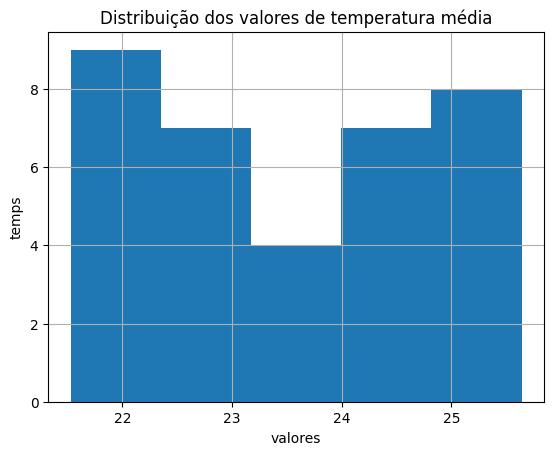

In [22]:
import matplotlib.pyplot as plt

df_mizera['TEMP_MEDIA'].dropna().hist(bins=5)
plt.title('Distribuição dos valores de temperatura média')
plt.xlabel('valores')
plt.ylabel('temps')
plt.show()

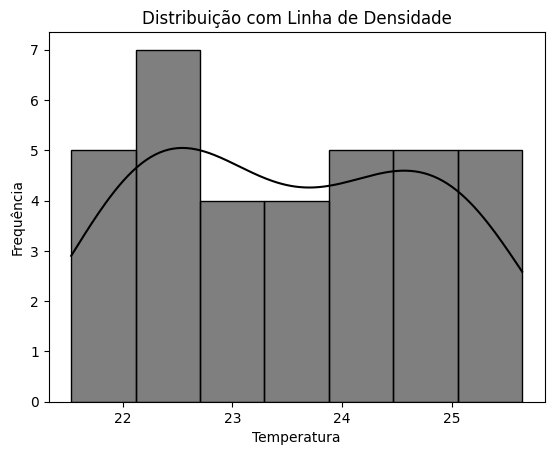

In [38]:
import seaborn as sns

sns.histplot(df_mizera['TEMP_MEDIA'],kde=True,color='black')
plt.title("Distribuição com Linha de Densidade")
plt.xlabel("Temperatura")
plt.ylabel("Frequência")
plt.show()

In [18]:
df_coisado= df_mizera['TEMP_MEDIA']

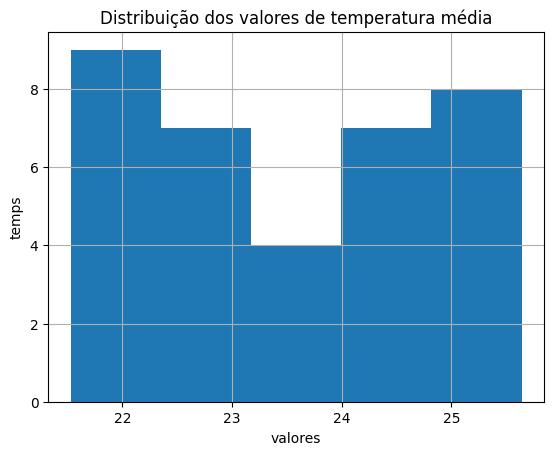

In [23]:
df_coisado.hist(bins=5)
plt.title('Distribuição dos valores de temperatura média')
plt.xlabel('valores')
plt.ylabel('temps')
plt.show()

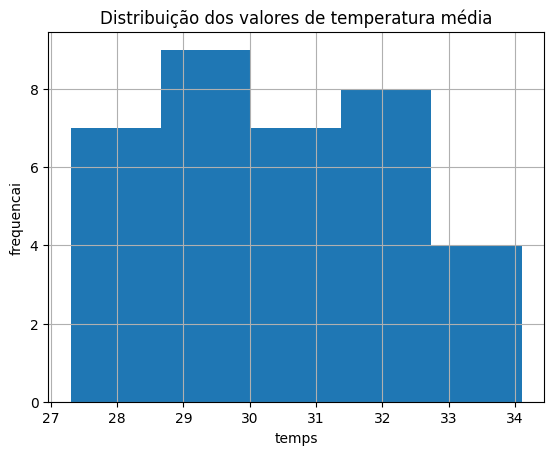

In [30]:
df_mizera['TEMP_MAX'].hist(bins=5)
plt.title('Distribuição dos valores de temperatura média')
plt.xlabel('temps')
plt.ylabel('frequencai')
plt.show()

In [26]:
df_mizera['TEMP_MAX']

,TEMP_MAX
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,NaN
7,NaN
8,NaN
9,NaN


In [40]:
mediana_maxima=df_mizera['TEMP_MAX'].dropna().median()
mediana_media= df_mizera['TEMP_MEDIA'].dropna().median()


In [41]:
df_mizera['TEMP_MAX'].fillna(mediana_maxima,inplace=True)
df_mizera['TEMP_MEDIA'].fillna(mediana_media,inplace=True)

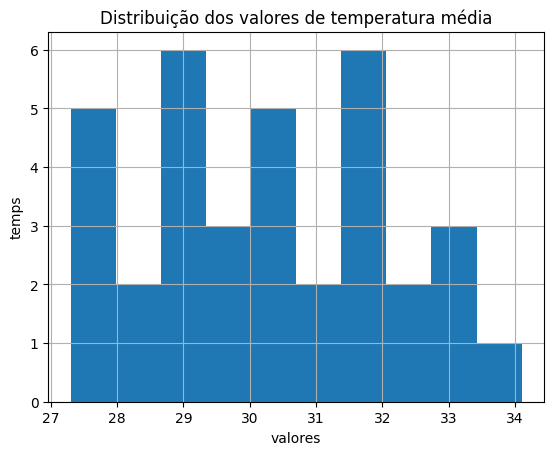

In [29]:
df_mizera['TEMP_MAX'].dropna().hist(bins=10)
plt.title('Distribuição dos valores de temperatura média')
plt.xlabel('valores')
plt.ylabel('temps')
plt.show()